**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 04. MCMC Bayesian Inference
This notebook demonstrates practical Bayesian modeling workflows with Numerics MCMC samplers.

## What You'll Learn

- Real-world Bayesian inference examples
- Comparing different MCMC samplers (RWMH vs DEMCz)
- **Performance benchmarks: Numerics vs PyMC** 
- Posterior predictive checks
- Model comparison

## Setup

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy import stats
from System import Array, Double
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

# Import MCMC classes
from Numerics.Sampling.MCMC import RWMH, DEMCzs, MCMCResults, LogLikelihood, MCMCSampler
from Numerics.Distributions import Normal, Uniform, Logistic, Gumbel, Weibull, IUnivariateDistribution
from Numerics.Mathematics.LinearAlgebra import Matrix
from helper_functions import create_comparison_table

print("✓ Setup complete")

✓ Setup complete


## Example 1: Flood Frequency Analysis

**Problem:** We have annual peak flow data and want to estimate distribution parameters with uncertainty.

**Data Source:** Tippecanoe River Near Delphi, Indiana (from "Flood Frequency Analysis", A.R. Rao & K.H. Hamed, CRC Press, 2000)

Flood Dataset Summary


,Metric,Value
0,Count,48.00
1,Sample mean (cfs),12665.21
2,Sample std (cfs),4709.74
3,Min (cfs),2700.00
4,Max (cfs),22600.00


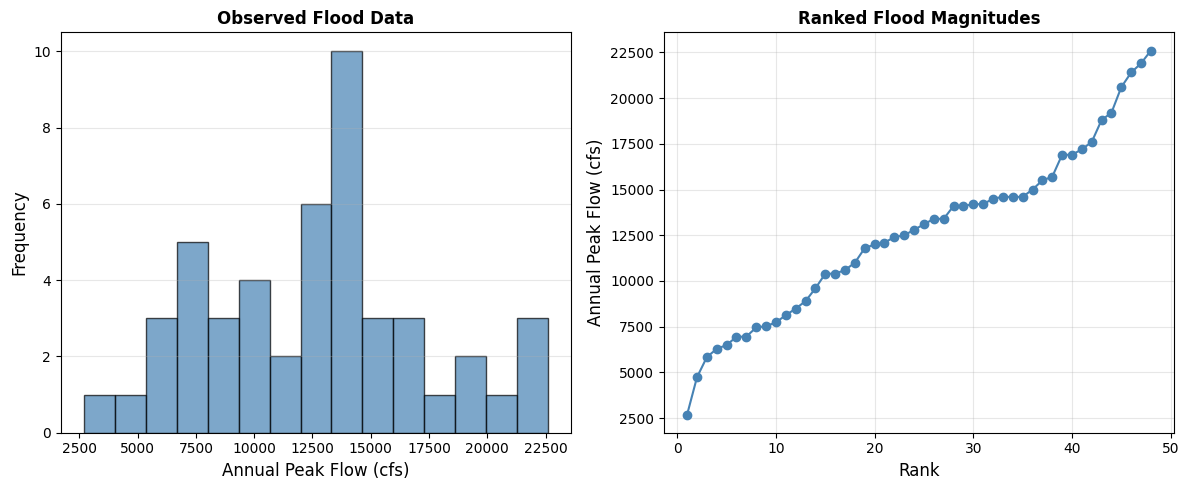

In [2]:
flood_data = Array[Double]([
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000, 
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600, 
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600, 
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600, 
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460
])

flood_np = np.array(list(flood_data))
summary_df = pd.DataFrame({
    'Metric': ['Count','Sample mean (cfs)','Sample std (cfs)','Min (cfs)','Max (cfs)'],
    'Value': [flood_data.Length, np.mean(flood_np), np.std(flood_np, ddof=1), np.min(flood_np), np.max(flood_np)]
})
print('Flood Dataset Summary')
display(summary_df.round(2))

# Visualize data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(flood_data, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Annual Peak Flow (cfs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Observed Flood Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
sorted_data = sorted(list(flood_data))
plt.plot(range(1, len(sorted_data)+1), sorted_data, 'o-', color='steelblue')
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Annual Peak Flow (cfs)', fontsize=12)
plt.title('Ranked Flood Magnitudes', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 1. Fitting a Normal Distribution

We'll estimate μ and σ for a Normal distribution using Bayesian inference.

In [3]:
# Create uniform priors based on data constraints
norm_dist = Normal()
constraints = norm_dist.GetParameterConstraints(flood_data)

mu_prior = Uniform(constraints.Item2[0], constraints.Item3[0])
sigma_prior = Uniform(constraints.Item2[1], constraints.Item3[1])

print(f"Prior for μ: Uniform({mu_prior.Minimum:.0f}, {mu_prior.Maximum:.0f})")
print(f"Prior for σ: Uniform({sigma_prior.Minimum:.0f}, {sigma_prior.Maximum:.0f})")

# Create prior list
priors = List[IUnivariateDistribution]()
priors.Add(mu_prior)
priors.Add(sigma_prior)

# Define log-likelihood
def log_likelihood_normal(params):
    mu = params[0]
    sigma = params[1]
    dist = Normal(mu, sigma)
    return dist.LogLikelihood(flood_data)

# Recall we have to wrap the Python function as a .NET Func
log_lik_func = LogLikelihood(log_likelihood_normal)

Prior for μ: Uniform(-1000000, 1000000)
Prior for σ: Uniform(0, 100000)


### 2. Compare RWMH vs DEMCzs Samplers

Let's run both samplers and compare their performance.

DEMCzs is often more efficient than RWMH for:
- High-dimensional problems
- Correlated parameters
- Multimodal distributions

**Performance Preview:** In the benchmark below, Numerics DEMCzs often runs faster than PyMC. Your results may vary by machine, sampler settings, and version.


In [4]:
# Run RWMH sampler
print("Running RWMH sampler...")
start_rwmh = time.perf_counter()
sampler_rwmh = RWMH(priors, log_lik_func, Matrix(2))
sampler_rwmh.Initialize = MCMCSampler.InitializationType.MAP
sampler_rwmh.Sample()
time_rwmh = time.perf_counter() - start_rwmh
results_rwmh = MCMCResults(sampler_rwmh)
print(f"✓ RWMH complete ({time_rwmh:.3f} seconds)")

# Run DEMCzs sampler
print("\nRunning DEMCzs sampler...")
start_demczs = time.perf_counter()
sampler_demczs = DEMCzs(priors, log_lik_func)
sampler_demczs.Sample()
time_demczs = time.perf_counter() - start_demczs
results_demczs = MCMCResults(sampler_demczs)
print(f"✓ DEMCzs complete ({time_demczs:.3f} seconds)")

print(f"\nSpeedup: DEMCzs is {time_rwmh/time_demczs:.2f}x faster than RWMH")

Running RWMH sampler...
✓ RWMH complete (19.570 seconds)

Running DEMCzs sampler...
✓ DEMCzs complete (17.324 seconds)

Speedup: DEMCzs is 1.13x faster than RWMH


### 3. Compare Results

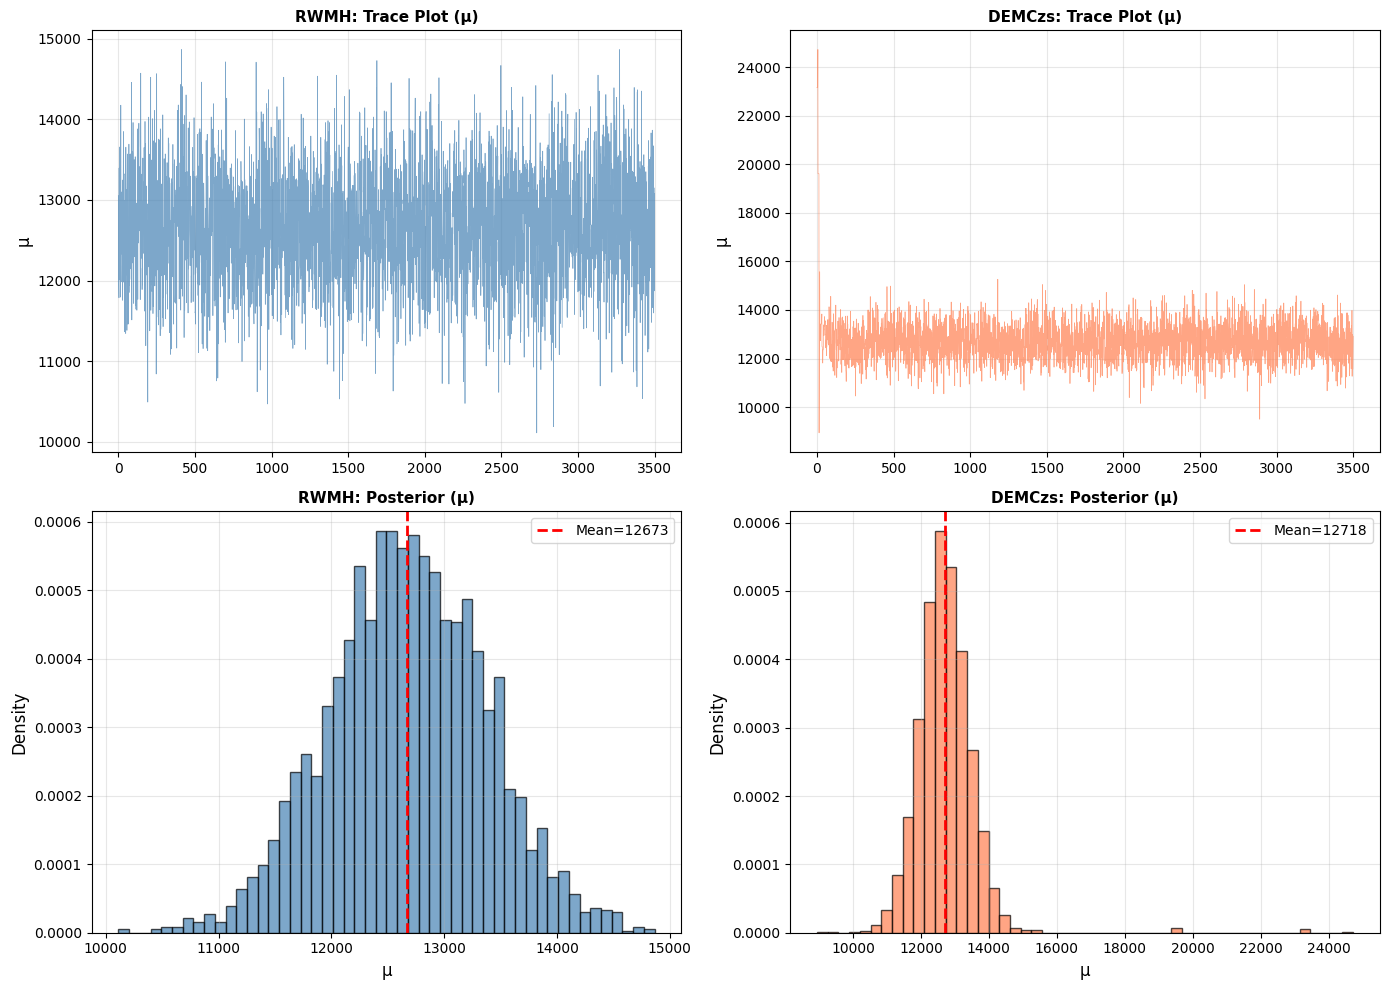

SAMPLER COMPARISON


,Statistic,RWMH,DEMCzs
0,Mean (μ),12664.471945,12655.494263
1,Std (μ),703.698295,701.338153
2,Mean (σ),4834.053320,4838.838605
3,Std (σ),514.951436,513.493502
4,Runtime (sec),19.569805,17.324444


In [5]:
# Extract samples
rwmh_mu = [results_rwmh.MarkovChains[0][i].Values[0] for i in range(len(results_rwmh.MarkovChains[0]))]
rwmh_sigma = [results_rwmh.MarkovChains[0][i].Values[1] for i in range(len(results_rwmh.MarkovChains[0]))]

demczs_mu = [results_demczs.MarkovChains[0][i].Values[0] for i in range(len(results_demczs.MarkovChains[0]))]
demczs_sigma = [results_demczs.MarkovChains[0][i].Values[1] for i in range(len(results_demczs.MarkovChains[0]))]

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mu trace plots
axes[0, 0].plot(rwmh_mu, linewidth=0.5, alpha=0.7, color='steelblue')
axes[0, 0].set_ylabel('μ', fontsize=12)
axes[0, 0].set_title('RWMH: Trace Plot (μ)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(demczs_mu, linewidth=0.5, alpha=0.7, color='coral')
axes[0, 1].set_ylabel('μ', fontsize=12)
axes[0, 1].set_title('DEMCzs: Trace Plot (μ)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Mu posterior distributions
axes[1, 0].hist(rwmh_mu, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[1, 0].axvline(np.mean(rwmh_mu), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(rwmh_mu):.0f}')
axes[1, 0].set_xlabel('μ', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('RWMH: Posterior (μ)', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(demczs_mu, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1, 1].axvline(np.mean(demczs_mu), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(demczs_mu):.0f}')
axes[1, 1].set_xlabel('μ', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('DEMCzs: Posterior (μ)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison table
comparison_df = pd.DataFrame({
    'Statistic': ['Mean (μ)', 'Std (μ)', 'Mean (σ)', 'Std (σ)', 'Runtime (sec)'],
    'RWMH': [
        results_rwmh.ParameterResults[0].SummaryStatistics.Mean,
        results_rwmh.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_rwmh.ParameterResults[1].SummaryStatistics.Mean,
        results_rwmh.ParameterResults[1].SummaryStatistics.StandardDeviation,
        time_rwmh
    ],
    'DEMCzs': [
        results_demczs.ParameterResults[0].SummaryStatistics.Mean,
        results_demczs.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_demczs.ParameterResults[1].SummaryStatistics.Mean,
        results_demczs.ParameterResults[1].SummaryStatistics.StandardDeviation,
        time_demczs
    ]
})

print("SAMPLER COMPARISON")
display(comparison_df)


## Performance Benchmark: Numerics vs PyMC
Now let's compare Numerics DEMCzs against Python's popular PyMC library.

**Note:** This requires PyMC to be installed:
```bash
pip install pymc arviz
```

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\GIT\Numerics-Python-Examples\.venv\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Numerics DEMCzs Performance:
  Runtime: 17.324 seconds
  Mean μ:  12655.49
  Mean σ:  4838.84

Running PyMC...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu, sigma]
Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 22 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


✓ PyMC complete (29.818 seconds)
  Mean μ:  12641.05
  Mean σ:  4826.64
PERFORMANCE COMPARISON: Numerics vs PyMC
Numerics DEMCzs:  17.324 seconds
PyMC (NUTS):      29.818 seconds
Speedup:          1.72x faster with Numerics


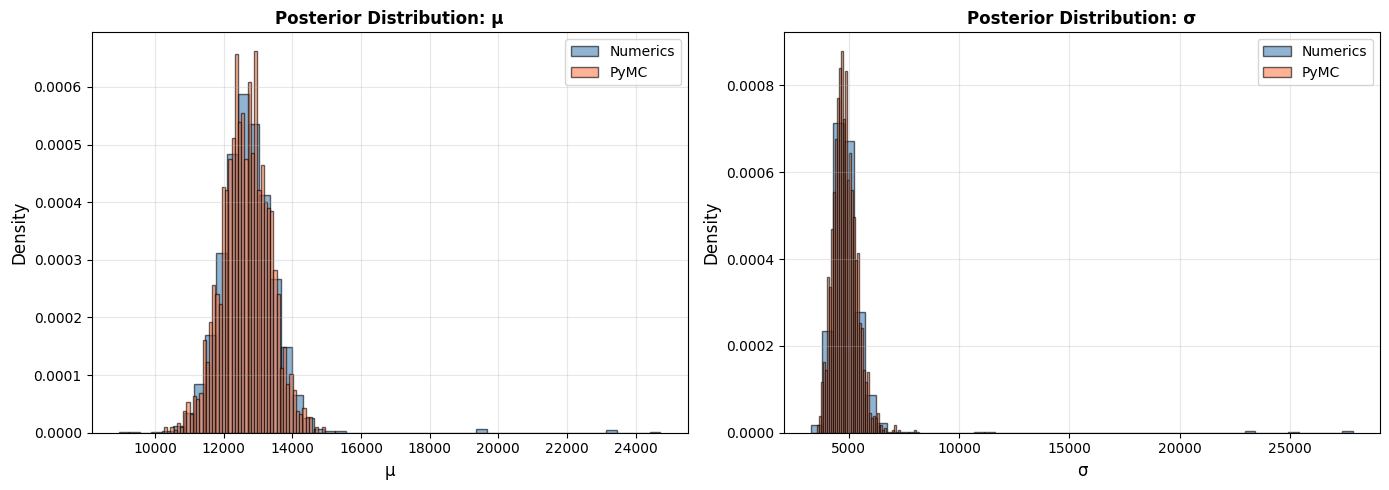

In [6]:
try:
    import pymc as pm
    
    # Numerics timing (reuse from above)
    print("Numerics DEMCzs Performance:")
    print(f"  Runtime: {time_demczs:.3f} seconds")
    print(f"  Mean μ:  {results_demczs.ParameterResults[0].SummaryStatistics.Mean:.2f}")
    print(f"  Mean σ:  {results_demczs.ParameterResults[1].SummaryStatistics.Mean:.2f}")
    
    # PyMC timing
    print("\nRunning PyMC...")
    pymc_start = time.perf_counter()
    
    pymc_data = np.array(list(flood_data))
    
    with pm.Model() as model:
        # Priors
        mu = pm.Uniform('mu', lower=constraints.Item2[0], upper=constraints.Item3[0])
        sigma = pm.Uniform('sigma', lower=constraints.Item2[1], upper=constraints.Item3[1])
        
        # Likelihood
        y = pm.Normal('y', mu=mu, sigma=sigma, observed=pymc_data)
        
        # Sample - tuned to match Numerics settings
        trace = pm.sample(draws=2000, tune=1000, chains=1, progressbar=False, random_seed=12345)
    
    pymc_time = time.perf_counter() - pymc_start
    
    # Extract PyMC results
    mu_samples_pymc = trace.posterior['mu'].values.flatten()
    sigma_samples_pymc = trace.posterior['sigma'].values.flatten()
    
    print(f"✓ PyMC complete ({pymc_time:.3f} seconds)")
    print(f"  Mean μ:  {np.mean(mu_samples_pymc):.2f}")
    print(f"  Mean σ:  {np.mean(sigma_samples_pymc):.2f}")
    
    # Performance comparison
    print("PERFORMANCE COMPARISON: Numerics vs PyMC")
    print(f"Numerics DEMCzs:  {time_demczs:.3f} seconds")
    print(f"PyMC (NUTS):      {pymc_time:.3f} seconds")
    print(f"Speedup:          {pymc_time/time_demczs:.2f}x faster with Numerics")
    
    # Visual comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(demczs_mu, bins=50, density=True, alpha=0.6, color='steelblue', label='Numerics', edgecolor='black')
    axes[0].hist(mu_samples_pymc, bins=50, density=True, alpha=0.6, color='coral', label='PyMC', edgecolor='black')
    axes[0].set_xlabel('μ', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].set_title('Posterior Distribution: μ', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(demczs_sigma, bins=50, density=True, alpha=0.6, color='steelblue', label='Numerics', edgecolor='black')
    axes[1].hist(sigma_samples_pymc, bins=50, density=True, alpha=0.6, color='coral', label='PyMC', edgecolor='black')
    axes[1].set_xlabel('σ', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].set_title('Posterior Distribution: σ', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("PyMC not installed. Skipping benchmark.")
    print("Install with: pip install pymc arviz")

## Example 2: Fitting a Logistic Distribution

**Data Source:** Same Tippecanoe River data

The Logistic distribution is often used for growth models and has heavier tails than Normal.

Fitting Logistic distribution with DEMCzs...
DEMCzs Complete (20.610 seconds)

Logistic Distribution Results


,Parameter,Posterior Mean,Lower 90% CI,Upper 90% CI
0,ξ (location),12630.20,11472.21,13791.70
1,α (scale),2824.51,2297.82,3447.05


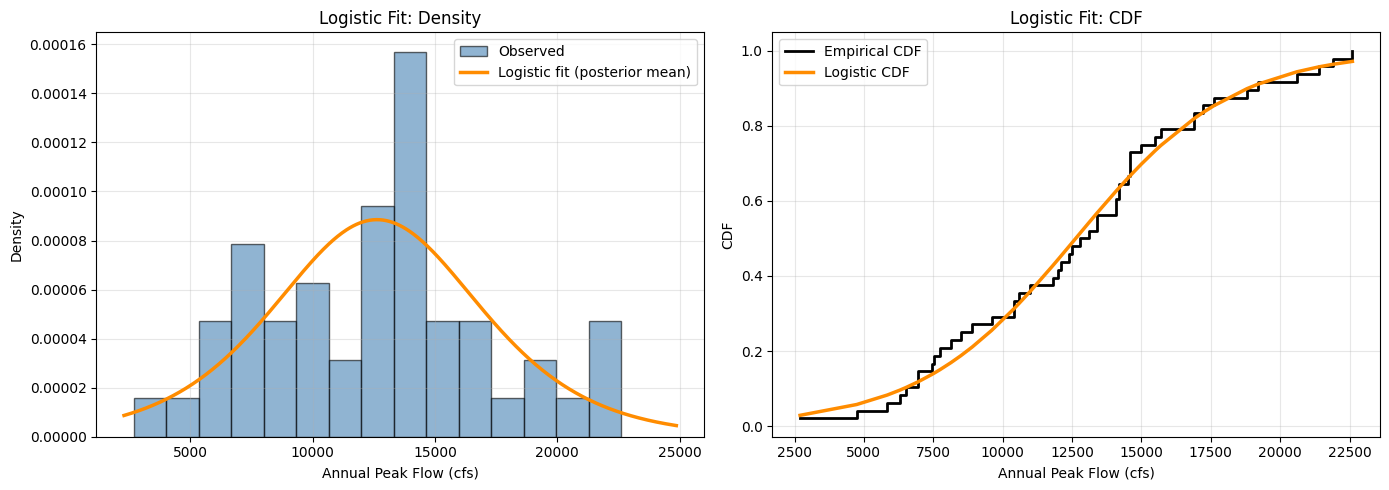

In [7]:
# Create priors for Logistic distribution
logistic_dist = Logistic()
constraints_log = logistic_dist.GetParameterConstraints(flood_data)

xi_prior = Uniform(constraints_log.Item2[0], constraints_log.Item3[0])
alpha_prior = Uniform(constraints_log.Item2[1], constraints_log.Item3[1])

priors_logistic = List[IUnivariateDistribution]()
priors_logistic.Add(xi_prior)
priors_logistic.Add(alpha_prior)

# Define log-likelihood
def log_likelihood_logistic(params):
    xi = params[0]
    alpha = params[1]
    dist = Logistic(xi, alpha)
    return dist.LogLikelihood(flood_data)

log_lik_logistic = LogLikelihood(log_likelihood_logistic)

# Run DEMCzs
print("Fitting Logistic distribution with DEMCzs...")
start = time.perf_counter()
sampler_logistic = DEMCzs(priors_logistic, log_lik_logistic)
sampler_logistic.Sample()
elapsed = time.perf_counter() - start
results_logistic = MCMCResults(sampler_logistic)
print(f"DEMCzs Complete ({elapsed:.3f} seconds)")

xi_stats = results_logistic.ParameterResults[0].SummaryStatistics
alpha_stats = results_logistic.ParameterResults[1].SummaryStatistics
results_table = pd.DataFrame([
    {'Parameter':'ξ (location)','Posterior Mean':xi_stats.Mean,'Lower 90% CI':xi_stats.LowerCI,'Upper 90% CI':xi_stats.UpperCI},
    {'Parameter':'α (scale)','Posterior Mean':alpha_stats.Mean,'Lower 90% CI':alpha_stats.LowerCI,'Upper 90% CI':alpha_stats.UpperCI},
])
print("\nLogistic Distribution Results")
display(results_table.round(2))

# Graph fitted Logistic distribution vs observed data
flood_np = np.array(list(flood_data))
fitted_logistic = Logistic(xi_stats.Mean, alpha_stats.Mean)
x_plot = np.linspace(flood_np.min() * 0.85, flood_np.max() * 1.10, 500)

fig, (ax_pdf, ax_cdf) = plt.subplots(1, 2, figsize=(14, 5))
ax_pdf.hist(flood_np, bins=15, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Observed')
ax_pdf.plot(x_plot, [fitted_logistic.PDF(xi) for xi in x_plot], color='darkorange', linewidth=2.5, label='Logistic fit (posterior mean)')
ax_pdf.set_xlabel('Annual Peak Flow (cfs)')
ax_pdf.set_ylabel('Density')
ax_pdf.set_title('Logistic Fit: Density')
ax_pdf.legend()
ax_pdf.grid(True, alpha=0.3)

sorted_obs = np.sort(flood_np)
ecdf = np.arange(1, len(sorted_obs) + 1) / len(sorted_obs)
ax_cdf.step(sorted_obs, ecdf, where='post', color='black', linewidth=2, label='Empirical CDF')
ax_cdf.plot(sorted_obs, [fitted_logistic.CDF(v) for v in sorted_obs], color='darkorange', linewidth=2.5, label='Logistic CDF')
ax_cdf.set_xlabel('Annual Peak Flow (cfs)')
ax_cdf.set_ylabel('CDF')
ax_cdf.set_title('Logistic Fit: CDF')
ax_cdf.legend()
ax_cdf.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Example 3: Comparing Multiple Distribution Fits

Let's fit several candidate distributions and compare their fit to the flood data.

We'll test:
1. Normal
2. Logistic  
3. Gumbel
4. Weibull

Fitting Gumbel distribution...
✓ Complete


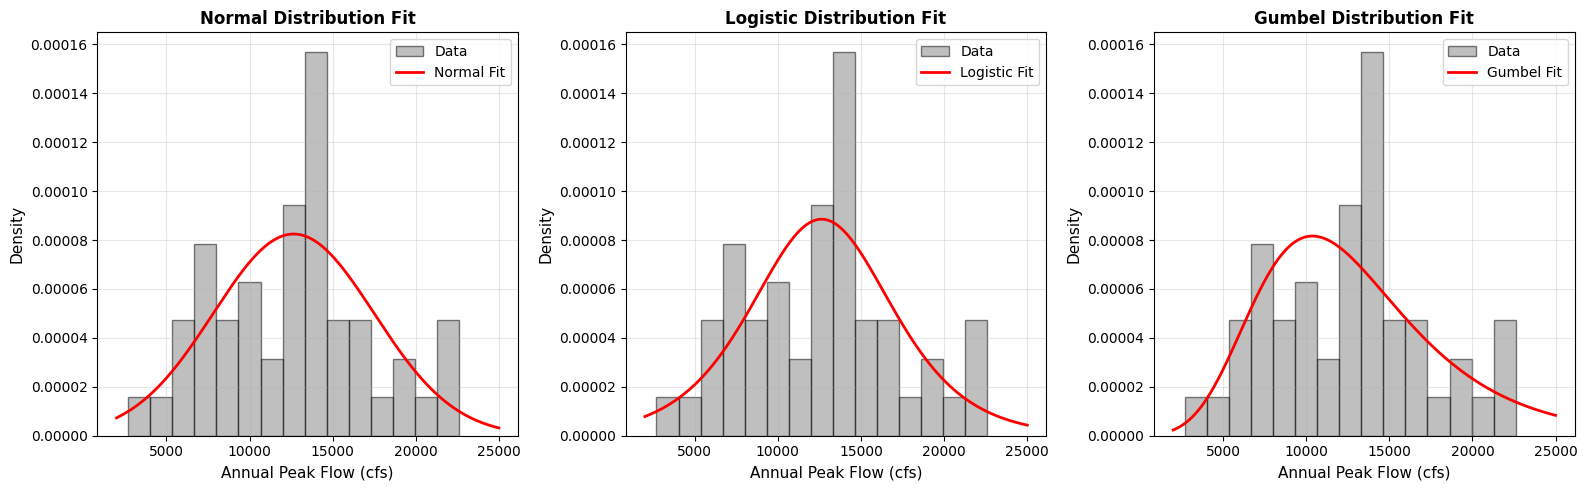

MODEL COMPARISON


,Distribution,Parameter 1,Parameter 2
0,Normal,μ = 12655,σ = 4839
1,Logistic,ξ = 12630,α = 2825
2,Gumbel,ξ = 10376,α = 4508


In [8]:
# We already have Normal and Logistic results
# Let's add Gumbel
gumbel_dist = Gumbel()
constraints_gum = gumbel_dist.GetParameterConstraints(flood_data)

xi_prior_g = Uniform(constraints_gum.Item2[0], constraints_gum.Item3[0])
alpha_prior_g = Uniform(constraints_gum.Item2[1], constraints_gum.Item3[1])

priors_gumbel = List[IUnivariateDistribution]()
priors_gumbel.Add(xi_prior_g)
priors_gumbel.Add(alpha_prior_g)

def log_likelihood_gumbel(params):
    dist = Gumbel(params[0], params[1])
    return dist.LogLikelihood(flood_data)

log_lik_gumbel = LogLikelihood(log_likelihood_gumbel)

print("Fitting Gumbel distribution...")
sampler_gumbel = DEMCzs(priors_gumbel, log_lik_gumbel)
sampler_gumbel.Sample()
results_gumbel = MCMCResults(sampler_gumbel)
print("✓ Complete")

# Compare all three distributions visually
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Extract parameter samples
normal_mu_mean = results_demczs.ParameterResults[0].SummaryStatistics.Mean
normal_sigma_mean = results_demczs.ParameterResults[1].SummaryStatistics.Mean

logistic_xi_mean = results_logistic.ParameterResults[0].SummaryStatistics.Mean
logistic_alpha_mean = results_logistic.ParameterResults[1].SummaryStatistics.Mean

gumbel_xi_mean = results_gumbel.ParameterResults[0].SummaryStatistics.Mean
gumbel_alpha_mean = results_gumbel.ParameterResults[1].SummaryStatistics.Mean

# Create fitted distributions
fitted_normal = Normal(normal_mu_mean, normal_sigma_mean)
fitted_logistic = Logistic(logistic_xi_mean, logistic_alpha_mean)
fitted_gumbel = Gumbel(gumbel_xi_mean, gumbel_alpha_mean)

# Plot data and fits
x = np.linspace(2000, 25000, 500)

for ax, dist, name in zip(axes, 
                          [fitted_normal, fitted_logistic, fitted_gumbel],
                          ['Normal', 'Logistic', 'Gumbel']):
    ax.hist(flood_data, bins=15, density=True, alpha=0.5, color='gray', edgecolor='black', label='Data')
    pdf = [dist.PDF(xi) for xi in x]
    ax.plot(x, pdf, linewidth=2, label=f'{name} Fit', color='red')
    ax.set_xlabel('Annual Peak Flow (cfs)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{name} Distribution Fit', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model comparison table
model_comparison = pd.DataFrame({
    'Distribution': ['Normal', 'Logistic', 'Gumbel'],
    'Parameter 1': [f'μ = {normal_mu_mean:.0f}', f'ξ = {logistic_xi_mean:.0f}', f'ξ = {gumbel_xi_mean:.0f}'],
    'Parameter 2': [f'σ = {normal_sigma_mean:.0f}', f'α = {logistic_alpha_mean:.0f}', f'α = {gumbel_alpha_mean:.0f}']
})

print("MODEL COMPARISON")
display(model_comparison)


## Posterior Predictive Checks

A key part of Bayesian modeling is checking if our model can reproduce the observed data.

Let's generate predictions from our fitted Normal distribution.

DEMCzs already gives posterior samples of parameters. Posterior predictive checks add one extra step: generate synthetic y_rep from p(y|θ) using θ sampled from the posterior.

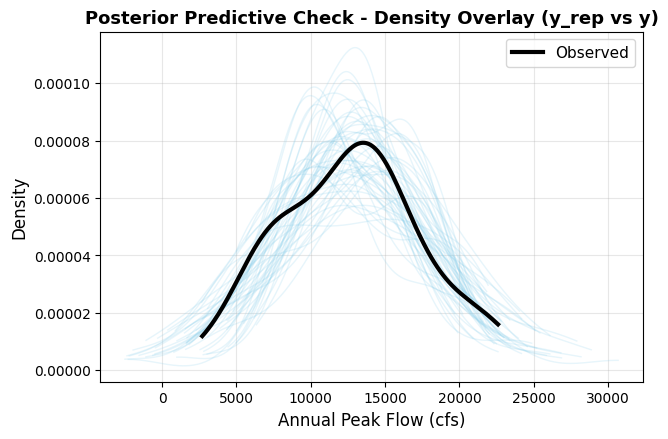

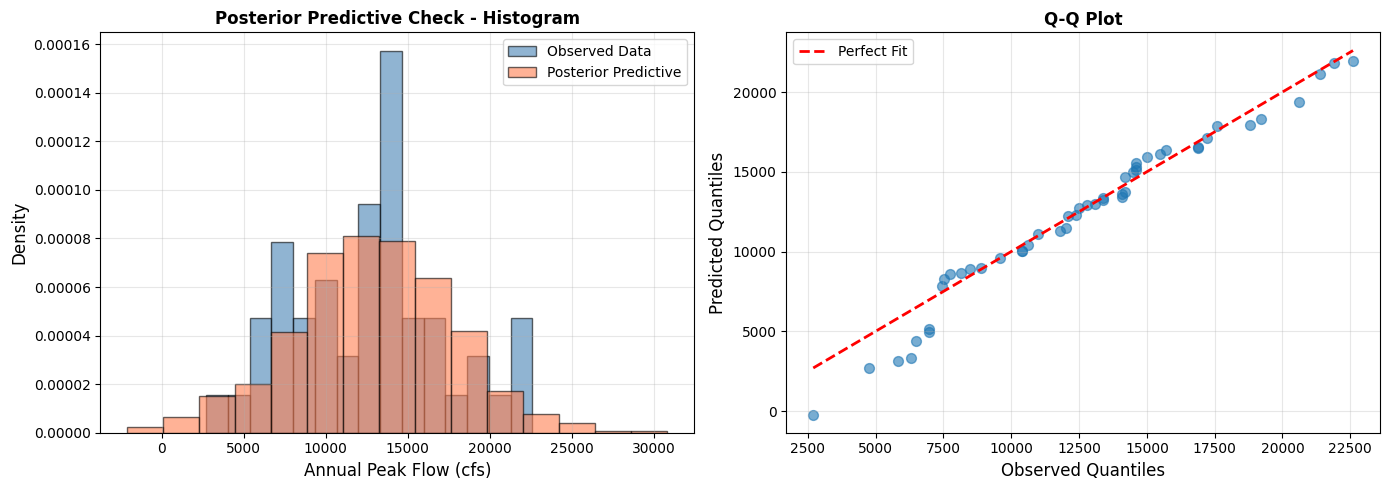


Posterior Predictive Summary


,Statistic,Observed,Posterior Predictive
0,Mean,12665.21,12923.95
1,Std Dev,4709.74,4903.65
2,5th percentile,5997.50,4387.79
3,95th percentile,21120.00,20783.57


In [14]:
# Settings for replications
n_replications = 50
n_predictions = 1000

predicted_data = []
replicated_datasets = []

posterior_mu_samples = demczs_mu[-1000:]
posterior_sigma_samples = demczs_sigma[-1000:]

# Draw posterior predictive values for distribution-level comparison
for _ in range(n_predictions):
    # Generate random index of our posterior
    idx = np.random.randint(0, len(posterior_mu_samples))
    # Pull that random sample's means and sigma
    mu = posterior_mu_samples[idx]
    sigma = posterior_sigma_samples[idx]
    # Fit a new distribution based on the drawn posterior values
    dist = Normal(mu, sigma)
    # Generate new data point from this new distribution
    # Characterize posterior
    predicted_data.append(list(dist.GenerateRandomValues(1))[0])

# Generate replicated datasets for density overlay
for _ in range(n_replications):
    # Generate random index of our posterior
    idx = np.random.randint(0, len(posterior_mu_samples))
    # Pull that random sample's mean and sigma
    mu = posterior_mu_samples[idx]
    sigma = posterior_sigma_samples[idx]
    # Fit a new distribution based on the drawn posterior values
    dist = Normal(mu, sigma)
    # Generate full dataset of new data from this distribution
    # Used for posterior check
    replicated_data = list(dist.GenerateRandomValues(len(flood_data)))
    replicated_datasets.append(replicated_data)

# Plot posterior predictive vs observed
fig = plt.figure(figsize=(7,10))
ax_density = fig.add_subplot(211)
for rep_data in replicated_datasets:
    kde = stats.gaussian_kde(rep_data)
    x_range = np.linspace(min(rep_data), max(rep_data), 200)
    ax_density.plot(x_range, kde(x_range), color='skyblue', alpha=0.2, linewidth=1)

observed_data = np.array(list(flood_data))
kde_obs = stats.gaussian_kde(observed_data)
x_range_obs = np.linspace(observed_data.min(), observed_data.max(), 200)
ax_density.plot(x_range_obs, kde_obs(x_range_obs), color='black', linewidth=3, label='Observed', zorder=10)
ax_density.set_xlabel('Annual Peak Flow (cfs)', fontsize=12)
ax_density.set_ylabel('Density', fontsize=12)
ax_density.set_title('Posterior Predictive Check - Density Overlay (y_rep vs y)', fontsize=13, fontweight='bold')
ax_density.legend(fontsize=11)
ax_density.grid(True, alpha=0.3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(observed_data, bins=15, density=True, alpha=0.6, color='steelblue', label='Observed Data', edgecolor='black')
ax1.hist(predicted_data, bins=15, density=True, alpha=0.6, color='coral', label='Posterior Predictive', edgecolor='black')
ax1.set_xlabel('Annual Peak Flow (cfs)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Posterior Predictive Check - Histogram', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

sorted_observed = np.sort(observed_data)
sorted_predicted = np.sort(predicted_data[:len(observed_data)])
ax2.scatter(sorted_observed, sorted_predicted, alpha=0.6, s=50)
ax2.plot([min(sorted_observed), max(sorted_observed)], [min(sorted_observed), max(sorted_observed)], 'r--', linewidth=2, label='Perfect Fit')
ax2.set_xlabel('Observed Quantiles', fontsize=12)
ax2.set_ylabel('Predicted Quantiles', fontsize=12)
ax2.set_title('Q-Q Plot', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ppc_summary = pd.DataFrame({
    'Statistic': ['Mean', 'Std Dev', '5th percentile', '95th percentile'],
    'Observed': [np.mean(observed_data), np.std(observed_data, ddof=1), np.percentile(observed_data, 5), np.percentile(observed_data, 95)],
    'Posterior Predictive': [np.mean(predicted_data), np.std(predicted_data, ddof=1), np.percentile(predicted_data, 5), np.percentile(predicted_data, 95)]
})

print("\nPosterior Predictive Summary")
display(ppc_summary.round(2))


## More PyMC Comparison Tests
Above we tested Numerics against PyMC for a Normal distribution. Below are more comparison tests for the various distributions in Numerics. Since MCMC methods rely on random number generation, Numerics results will not be exactly the same as those produced by PyMC. Therefore, these comparisons aim to verify whether the results are within 5% of each other.

**Note:** The code block below takes a long time to run; a lot longer than the cells we've been running above.

In [10]:
try:
    import pymc as pm

    # Shared PyMC data
    pymc_data = np.array(list(flood_data))

    # Logistic distribution Comparison
    print("Logistic Distribution [PyMC Comparison]")

    log = Logistic()
    constraints_log = log.GetParameterConstraints(flood_data)
    xi_prior = Uniform(constraints_log.Item2[0], constraints_log.Item3[0])
    alpha_prior = Uniform(constraints_log.Item2[1], constraints_log.Item3[1])
    priors_logistic = List[IUnivariateDistribution]()
    priors_logistic.Add(xi_prior)
    priors_logistic.Add(alpha_prior)

    def log_likelihood_logistic(params):
        dist = Logistic(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    log_lik_func = LogLikelihood(log_likelihood_logistic)

    log_numerics_start = time.perf_counter()
    sampler_logistic = DEMCzs(priors_logistic, log_lik_func)
    sampler_logistic.Sample()
    results_logistic = MCMCResults(sampler_logistic)
    log_numerics_time = time.perf_counter() - log_numerics_start

    log_pymc_start = time.perf_counter()

    with pm.Model() as model:
        xi = pm.Uniform('xi', lower=constraints_log.Item2[0], upper=constraints_log.Item3[0])
        alpha = pm.Uniform('alpha', lower=constraints_log.Item2[1], upper=constraints_log.Item3[1])
        y = pm.Logistic('y', mu=xi, s=alpha, observed=pymc_data)
        trace = pm.sample(draws=2000, tune=1000, chains=1, progressbar=False, random_seed=12345)

    xiSamples = trace.posterior['xi'].values.flatten()
    alphaSamples = trace.posterior['alpha'].values.flatten()

    log_pymc_time = time.perf_counter() - log_pymc_start

    numericsResults = [
        results_logistic.ParameterResults[0].SummaryStatistics.Mean,
        results_logistic.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_logistic.ParameterResults[0].SummaryStatistics.LowerCI,
        results_logistic.ParameterResults[0].SummaryStatistics.Median,
        results_logistic.ParameterResults[0].SummaryStatistics.UpperCI,
        results_logistic.ParameterResults[1].SummaryStatistics.Mean,
        results_logistic.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_logistic.ParameterResults[1].SummaryStatistics.LowerCI,
        results_logistic.ParameterResults[1].SummaryStatistics.Median,
        results_logistic.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    comparisonResults = [
        np.mean(xiSamples), np.std(xiSamples), np.percentile(xiSamples, 5), np.median(xiSamples), np.percentile(xiSamples, 95),
        np.mean(alphaSamples), np.std(alphaSamples), np.percentile(alphaSamples, 5), np.median(alphaSamples), np.percentile(alphaSamples, 95)
    ]

    parameterNames = ['Xi Mean', 'Xi StdDev', 'Xi Lower CI', 'Xi Median', 'Xi Upper CI',
                      'Alpha Mean', 'Alpha StdDev', 'Alpha Lower CI', 'Alpha Median', 'Alpha Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, log_numerics_time, log_pymc_time)
    display(comparison_df)
    print(f"Speedup: {log_pymc_time/log_numerics_time:.2f}x faster with Numerics\n")

    # Gumbel distribution Comparison
    print("Gumbel Distribution [PyMC Comparison]")

    gumbel = Gumbel()
    constraints_gumbel = gumbel.GetParameterConstraints(flood_data)
    xi_prior = Uniform(constraints_gumbel.Item2[0], constraints_gumbel.Item3[0])
    alpha_prior = Uniform(constraints_gumbel.Item2[1], constraints_gumbel.Item3[1])
    priors_gumbel = List[IUnivariateDistribution]()
    priors_gumbel.Add(xi_prior)
    priors_gumbel.Add(alpha_prior)

    def log_likelihood_gumbel(params):
        dist = Gumbel(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    gumbel_lik_func = LogLikelihood(log_likelihood_gumbel)

    gumbel_numerics_start = time.perf_counter()
    sampler_gumbel = DEMCzs(priors_gumbel, gumbel_lik_func)
    sampler_gumbel.Sample()
    results_gumbel = MCMCResults(sampler_gumbel)
    gumbel_numerics_time = time.perf_counter() - gumbel_numerics_start

    gumbel_pymc_start = time.perf_counter()

    with pm.Model() as model:
        xi = pm.Uniform('xi', lower=constraints_gumbel.Item2[0], upper=constraints_gumbel.Item3[0])
        alpha = pm.Uniform('alpha', lower=constraints_gumbel.Item2[1], upper=constraints_gumbel.Item3[1])
        y = pm.Gumbel('y', mu=xi, beta=alpha, observed=pymc_data)
        trace = pm.sample(draws=2000, tune=1000, chains=1, progressbar=False, random_seed=12345)

    xiSamples = trace.posterior['xi'].values.flatten()
    alphaSamples = trace.posterior['alpha'].values.flatten()

    gumbel_pymc_time = time.perf_counter() - gumbel_pymc_start

    numericsResults = [
        results_gumbel.ParameterResults[0].SummaryStatistics.Mean,
        results_gumbel.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_gumbel.ParameterResults[0].SummaryStatistics.LowerCI,
        results_gumbel.ParameterResults[0].SummaryStatistics.Median,
        results_gumbel.ParameterResults[0].SummaryStatistics.UpperCI,
        results_gumbel.ParameterResults[1].SummaryStatistics.Mean,
        results_gumbel.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_gumbel.ParameterResults[1].SummaryStatistics.LowerCI,
        results_gumbel.ParameterResults[1].SummaryStatistics.Median,
        results_gumbel.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    comparisonResults = [
        np.mean(xiSamples), np.std(xiSamples), np.percentile(xiSamples, 5), np.median(xiSamples), np.percentile(xiSamples, 95),
        np.mean(alphaSamples), np.std(alphaSamples), np.percentile(alphaSamples, 5), np.median(alphaSamples), np.percentile(alphaSamples, 95)
    ]

    parameterNames = ['Xi Mean', 'Xi StdDev', 'Xi Lower CI', 'Xi Median', 'Xi Upper CI',
                      'Alpha Mean', 'Alpha StdDev', 'Alpha Lower CI', 'Alpha Median', 'Alpha Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, gumbel_numerics_time, gumbel_pymc_time)
    display(comparison_df)
    print(f"Speedup: {gumbel_pymc_time/gumbel_numerics_time:.2f}x faster with Numerics\n")

    # Weibull distribution Comparison
    print("Weibull Distribution [PyMC Comparison]")

    weibull = Weibull()
    constraints_weibull = weibull.GetParameterConstraints(flood_data)
    lambda_prior = Uniform(constraints_weibull.Item2[0], constraints_weibull.Item3[0])
    kappa_prior = Uniform(constraints_weibull.Item2[1], constraints_weibull.Item3[1])
    priors_weibull = List[IUnivariateDistribution]()
    priors_weibull.Add(lambda_prior)
    priors_weibull.Add(kappa_prior)

    def log_likelihood_weibull(params):
        dist = Weibull(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    weibull_lik_func = LogLikelihood(log_likelihood_weibull)

    weibull_numerics_start = time.perf_counter()
    sampler_weibull = DEMCzs(priors_weibull, weibull_lik_func)
    sampler_weibull.Sample()
    results_weibull = MCMCResults(sampler_weibull)
    weibull_numerics_time = time.perf_counter() - weibull_numerics_start

    weibull_pymc_start = time.perf_counter()

    with pm.Model() as model:
        kappa = pm.Uniform('kappa', lower=constraints_weibull.Item2[1], upper=constraints_weibull.Item3[1])
        lambda_ = pm.Uniform('lambda', lower=constraints_weibull.Item2[0], upper=constraints_weibull.Item3[0])
        y = pm.Weibull('y', alpha=kappa, beta=lambda_, observed=pymc_data)
        trace = pm.sample(draws=2000, tune=1000, chains=1, progressbar=False, random_seed=12345)

    kappaSamples = trace.posterior['kappa'].values.flatten()
    lambdaSamples = trace.posterior['lambda'].values.flatten()

    weibull_pymc_time = time.perf_counter() - weibull_pymc_start

    numericsResults = [
        results_weibull.ParameterResults[0].SummaryStatistics.Mean,
        results_weibull.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_weibull.ParameterResults[0].SummaryStatistics.LowerCI,
        results_weibull.ParameterResults[0].SummaryStatistics.Median,
        results_weibull.ParameterResults[0].SummaryStatistics.UpperCI,
        results_weibull.ParameterResults[1].SummaryStatistics.Mean,
        results_weibull.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_weibull.ParameterResults[1].SummaryStatistics.LowerCI,
        results_weibull.ParameterResults[1].SummaryStatistics.Median,
        results_weibull.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    comparisonResults = [
        np.mean(kappaSamples), np.std(kappaSamples), np.percentile(kappaSamples, 5), np.median(kappaSamples), np.percentile(kappaSamples, 95),
        np.mean(lambdaSamples), np.std(lambdaSamples), np.percentile(lambdaSamples, 5), np.median(lambdaSamples), np.percentile(lambdaSamples, 95)
    ]

    parameterNames = ['Kappa Mean', 'Kappa StdDev', 'Kappa Lower CI', 'Kappa Median', 'Kappa Upper CI',
                      'Lambda Mean', 'Lambda StdDev', 'Lambda Lower CI', 'Lambda Median', 'Lambda Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, weibull_numerics_time, weibull_pymc_time)
    display(comparison_df)
    print(f"Speedup: {weibull_pymc_time/weibull_numerics_time:.2f}x faster with Numerics\n")

except ImportError:
    print("PyMC not installed. Skipping benchmark.")
    print("Install with: pip install pymc arviz")


Logistic Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [xi, alpha]
Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 28 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


,Parameter,Numerics Result,PyMC Result,Difference
0,Xi Mean,12630.200879,12629.776684,0.0034%
1,Xi StdDev,709.598855,750.396411,-5.4368%
2,Xi Lower CI,11472.206785,11412.040159,0.5272%
3,Xi Median,12631.443174,12621.790025,0.0765%
4,Xi Upper CI,13791.697452,13868.495589,-0.5538%
5,Alpha Mean,2824.50542,2840.054691,-0.5475%
6,Alpha StdDev,352.853173,363.498638,-2.9286%
7,Alpha Lower CI,2297.817553,2294.332482,0.1519%
8,Alpha Median,2795.192763,2811.32883,-0.5740%
9,Alpha Upper CI,3447.047966,3480.577224,-0.9633%


Speedup: 1.53x faster with Numerics

Gumbel Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [xi, alpha]
Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 23 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


,Parameter,Numerics Result,PyMC Result,Difference
0,Xi Mean,10376.330635,10382.284923,-0.0574%
1,Xi StdDev,700.434572,681.089775,2.8403%
2,Xi Lower CI,9251.808366,9321.934034,-0.7523%
3,Xi Median,10369.92479,10357.422054,0.1207%
4,Xi Upper CI,11551.017071,11586.426811,-0.3056%
5,Alpha Mean,4507.589858,4499.941672,0.1700%
6,Alpha StdDev,506.615982,527.084645,-3.8834%
7,Alpha Lower CI,3752.989571,3734.738335,0.4887%
8,Alpha Median,4463.712922,4439.996565,0.5342%
9,Alpha Upper CI,5392.367283,5432.100265,-0.7314%


Speedup: 1.25x faster with Numerics

Weibull Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [kappa, lambda]
Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 27 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


,Parameter,Numerics Result,PyMC Result,Difference
0,Kappa Mean,14302.461206,2.979863,479870.3975%
1,Kappa StdDev,751.021412,0.337588,222366.9669%
2,Kappa Lower CI,13101.191308,2.454716,533615.1934%
3,Kappa Median,14275.825692,2.966317,481164.3126%
4,Kappa Upper CI,15567.138823,3.54857,438587.6470%
5,Lambda Mean,2.981612,14305.408239,-99.9792%
6,Lambda StdDev,0.336381,747.594243,-99.9550%
7,Lambda Lower CI,2.445549,13083.950471,-99.9813%
8,Lambda Median,2.973241,14301.087779,-99.9792%
9,Lambda Upper CI,3.547739,15522.938273,-99.9771%


Speedup: 1.56x faster with Numerics



## Linear Regression with Uncertainty
We estimate regression coefficients with MCMC and quantify uncertainty with credible intervals.


Bayesian Linear Regression Summary


,Parameter,True,Posterior Mean,Lower 90% CI,Upper 90% CI
0,a (intercept),2.0,2.086,1.781,2.390
1,b (slope),1.5,1.488,1.436,1.541
2,sigma (noise sd),1.0,0.670,0.566,0.797


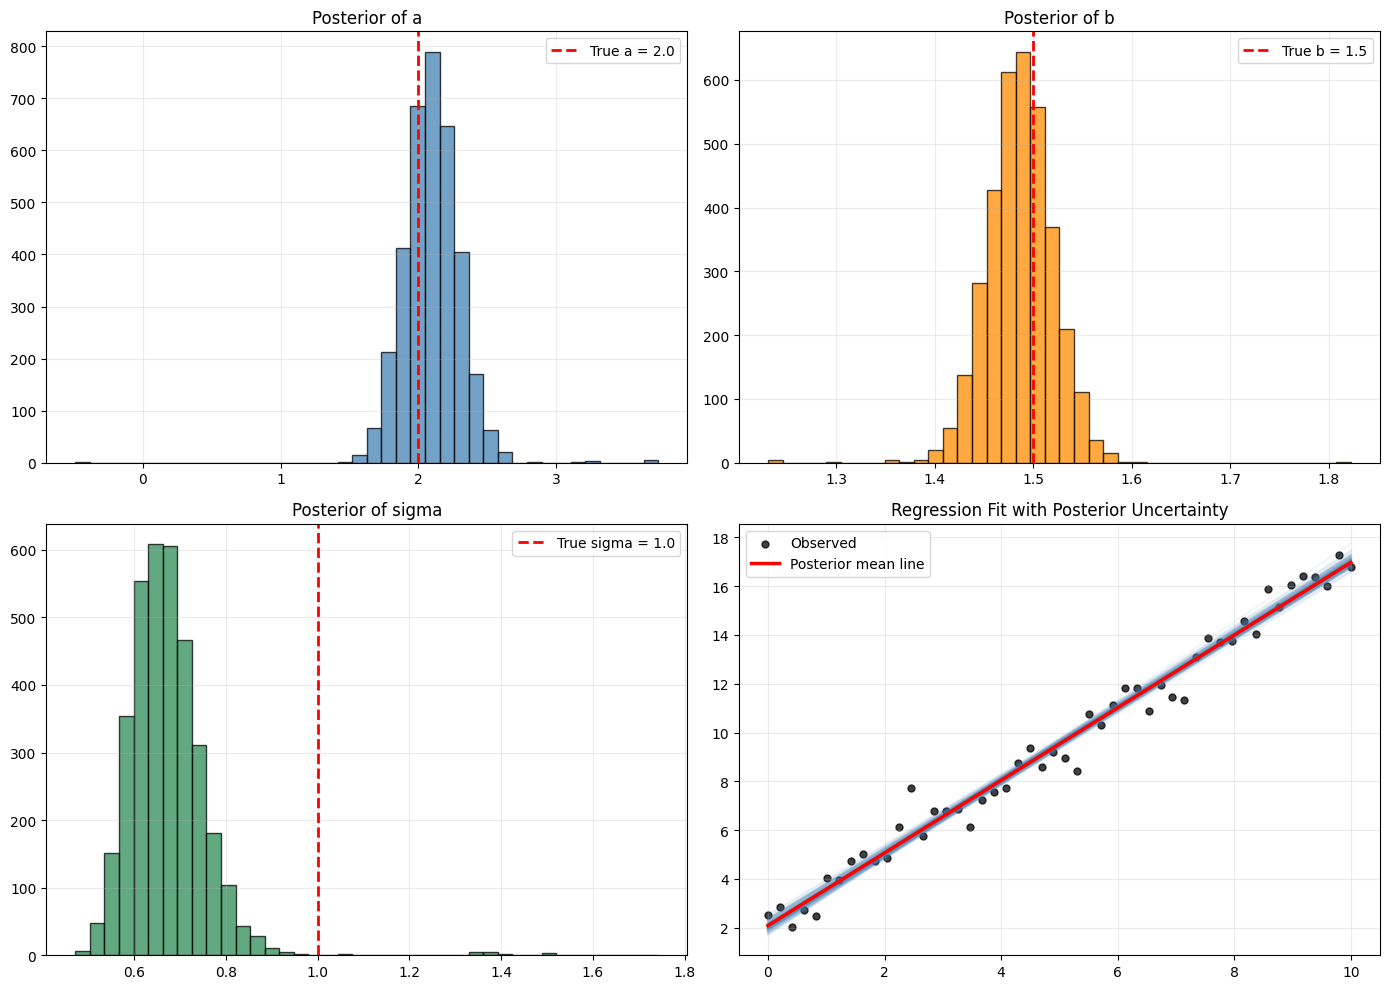

In [11]:
# Linear regression with uncertainty (y = a + b x + ε)
# More of this in notebook 10. Linear Models
np.random.seed(123)
x = np.linspace(0, 10, 50)
true_a, true_b, true_sigma = 2.0, 1.5, 1.0
y = true_a + true_b * x + list(Normal(0, true_sigma).GenerateRandomValues(len(x), 123))
data = Array[Double](y)

# Priors: a ~ Uniform, b ~ Uniform, sigma ~ Uniform
priors = List[IUnivariateDistribution]()
priors.Add(Uniform(-10, 10))
priors.Add(Uniform(0, 5))
priors.Add(Uniform(0.1, 5))

def log_likelihood_lin(params):
    a, b, sigma = params[0], params[1], params[2]
    mu = a + b * x
    dist = Normal(0, sigma)
    return sum(dist.LogPDF(y[i] - mu[i]) for i in range(len(y)))

log_lik = LogLikelihood(log_likelihood_lin)
# Run sampler
sampler_lr = DEMCzs(priors, log_lik)
sampler_lr.Sample()
results_lr = MCMCResults(sampler_lr)

# Pull out posterior chains for each coefficient (for plotting)
a_samples = [results_lr.MarkovChains[0][i].Values[0] for i in range(len(results_lr.MarkovChains[0]))]
b_samples = [results_lr.MarkovChains[0][i].Values[1] for i in range(len(results_lr.MarkovChains[0]))]
sigma_samples = [results_lr.MarkovChains[0][i].Values[2] for i in range(len(results_lr.MarkovChains[0]))]

# Pull out posterior values
lr_summary = pd.DataFrame([
    {'Parameter':'a (intercept)','True':true_a,'Posterior Mean':results_lr.ParameterResults[0].SummaryStatistics.Mean,'Lower 90% CI':results_lr.ParameterResults[0].SummaryStatistics.LowerCI,'Upper 90% CI':results_lr.ParameterResults[0].SummaryStatistics.UpperCI},
    {'Parameter':'b (slope)','True':true_b,'Posterior Mean':results_lr.ParameterResults[1].SummaryStatistics.Mean,'Lower 90% CI':results_lr.ParameterResults[1].SummaryStatistics.LowerCI,'Upper 90% CI':results_lr.ParameterResults[1].SummaryStatistics.UpperCI},
    {'Parameter':'sigma (noise sd)','True':true_sigma,'Posterior Mean':results_lr.ParameterResults[2].SummaryStatistics.Mean,'Lower 90% CI':results_lr.ParameterResults[2].SummaryStatistics.LowerCI,'Upper 90% CI':results_lr.ParameterResults[2].SummaryStatistics.UpperCI},
])
print('Bayesian Linear Regression Summary')
display(lr_summary.round(3))

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs[0, 0].hist(a_samples, bins=40, color='steelblue', alpha=0.75, edgecolor='black')
axs[0, 0].axvline(true_a, color='red', linestyle='--', linewidth=2, label=f'True a = {true_a}')
axs[0, 0].set_title('Posterior of a')
axs[0, 0].legend()

axs[0, 1].hist(b_samples, bins=40, color='darkorange', alpha=0.75, edgecolor='black')
axs[0, 1].axvline(true_b, color='red', linestyle='--', linewidth=2, label=f'True b = {true_b}')
axs[0, 1].set_title('Posterior of b')
axs[0, 1].legend()

axs[1, 0].hist(sigma_samples, bins=40, color='seagreen', alpha=0.75, edgecolor='black')
axs[1, 0].axvline(true_sigma, color='red', linestyle='--', linewidth=2, label=f'True sigma = {true_sigma}')
axs[1, 0].set_title('Posterior of sigma')
axs[1, 0].legend()

axs[1, 1].scatter(x, y, alpha=0.75, color='black', s=25, label='Observed')
x_line = np.linspace(x.min(), x.max(), 200)
draw_idx = np.random.choice(len(a_samples), size=min(100, len(a_samples)), replace=False)
for idx in draw_idx:
    axs[1, 1].plot(x_line, a_samples[idx] + b_samples[idx] * x_line, color='steelblue', alpha=0.08)
mean_a = results_lr.ParameterResults[0].SummaryStatistics.Mean
mean_b = results_lr.ParameterResults[1].SummaryStatistics.Mean
axs[1, 1].plot(x_line, mean_a + mean_b * x_line, color='red', linewidth=2.5, label='Posterior mean line')
axs[1, 1].set_title('Regression Fit with Posterior Uncertainty')
axs[1, 1].legend()

for ax in axs.flat:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## Summary
In this notebook you:

✓ Applied Bayesian inference to real flood-frequency data.     
✓ Fit multiple distributions with MCMC and compared posterior parameter estimates.     
✓ Performed posterior predictive checks to evaluate model realism.     
✓ Benchmarked Numerics against PyMC on representative models.      
✓ Built a Bayesian linear regression with credible intervals on model parameters.      

Key takeaway: Bayesian workflows in Numerics provide practical uncertainty quantification while remaining competitive in performance.

## Exercise
1. Fit a Gumbel distribution with both RWMH and DEMCzs.
2. Compare posterior means and credible intervals.
3. Which sampler mixes faster?
